# 01 - Region Introduction: *Case study region and its seasonal patterns*

In [1]:
# Basic imports
import os
import numpy as np
import pandas as pd

from pathlib import Path

# Plotting packages
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Geodata handlers
import xarray as xr
import geopandas as gpd
from shapely.geometry import mapping, Polygon
from shapely.ops import unary_union

from mpl_toolkits.axes_grid1 import make_axes_locatable
import cmasher as cmr
from xseas.utils import day_of_year_to_date

import matplotlib as mpl
# Set the default font size for the plots
# Imposta stile globale
mpl.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 11,
    'axes.edgecolor': 'black',
    'axes.linewidth': 1,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

In [2]:
FIGURES_DIR = Path('/Users/jacopograssi/Documents/Paper-seasonality/figures')
SUPP_FIGURES_DIR = Path('/Users/jacopograssi/Documents/Paper-seasonality/figures_supplementary')
print(f"Figures dir: {FIGURES_DIR}")
print(f"Supplementary figures dir: {SUPP_FIGURES_DIR}")

Figures dir: /Users/jacopograssi/Documents/Paper-seasonality/figures
Supplementary figures dir: /Users/jacopograssi/Documents/Paper-seasonality/figures_supplementary


In [ ]:
# Define base paths relative to notebook location
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
WORKING_FOLDER = PROJECT_ROOT / 'working_folder'

# Ensure figures directory exists
FIGURES_DIR.mkdir(exist_ok=True)

# Define key paths
SHAPEFILES_PATH = WORKING_FOLDER / 'shapefiles'
REFERENCES_PATH = WORKING_FOLDER / 'references'
DATA_PATH = WORKING_FOLDER / 'data'
CONFIG_FILE = 'four_seas_all_vars.yaml'

print(f"Project root: {PROJECT_ROOT}")
print(f"Working folder: {WORKING_FOLDER}")
print(f"Figures directory: {FIGURES_DIR}")

Project root: /Users/jacopograssi/Documents/XSeas
Working folder: /Users/jacopograssi/Documents/XSeas/working_folder
Figures directory: /Users/jacopograssi/Documents/Paper-seasonality/figures


## Case study region
The study area analyzed in this work is the Indian subcontinent with a focus on the Hindu-Kush Karakoram/Himalaya region (HKKH).

As we will see later the interesting features of this area are:
- Two different seasonal patterns are detectable in the same region.
- The features of one of the two seasonal pattern, the Indian Summer Monsoon, are deeply exploited in scientific literature. This gives us a strong stsrting point for evaluating a machine learning algorithm which aims to detect the meteorological seasons.



--- 
### Boundaries data
The **administrative boundary data** are taken from [GADM](https://gadm.org/about.html), version 4.1. Data are distributed in GeoPackage format. Two different files are used:
- World: contains the first level (countries) for the entire world (*data/raw/external/GADM41_WORLD.gpkg*)
- India: contains the four administration levels of India (*data/raw/external/GADM41_IND.gpkg*)

The *administrative division of India* follows this scheme:
- Level 0: Country
- Level 1: States and union territories
- Level 2: District
- Level 3: Taluc

<sub><sup> *DISCLAIMER: Some regions in this area are disputed between states. The authors do not take responsibility for the borders shown, which are sourced from the GADM dataset.* </sup></sub>

The **regional data** for the Hindu Kush-Karakoram/Himalayas region are tacken from Palazzi et al, 2012


In [4]:
# -- BOUNDARIES DATA
# Geopackage with boundaries
boundary_file   = SHAPEFILES_PATH / 'boundary.gpkg'

# Geodataframe for boudaries
boundary = gpd.read_file(boundary_file)

if not os.path.exists(SHAPEFILES_PATH / "India.gpkg"):
    # Extracting the India shapefile
    india = boundary[boundary['COUNTRY'] == 'India']
    india.to_file(SHAPEFILES_PATH / "India.gpkg")

else:
    india = gpd.read_file(SHAPEFILES_PATH / "India.gpkg")

if not os.path.exists(SHAPEFILES_PATH / "HKK.gpkg"):
    
    # Defining the custom regions (based on Palazzi et al, 2012)
    hkk = gpd.GeoDataFrame({'geometry': [Polygon([(71, 32), (78, 32), (78, 37), (71, 37)])], 'short_name': 'hkk', 'long_name': 'Hindu Kush-Karakoram'}, crs=boundary.crs)
    hkk.to_file(SHAPEFILES_PATH / "HKK.gpkg")

else:
    hkk = gpd.read_file(SHAPEFILES_PATH / "HKK.gpkg")

if not os.path.exists(SHAPEFILES_PATH / "him.gpkg"):
    him = gpd.GeoDataFrame({'geometry': [Polygon([(78, 25), (93, 25), (93, 32), (78, 32)])], 'short_name': 'him', 'long_name': 'Himalayas'}, crs=boundary.crs)
    him.to_file(SHAPEFILES_PATH / "him.gpkg")

else:
    him = gpd.read_file(SHAPEFILES_PATH / "him.gpkg")


if not os.path.exists(SHAPEFILES_PATH / "central_india.gpkg"):
    central_india = gpd.GeoDataFrame({'geometry': [Polygon([(75, 15.5), (85, 15.5), (85, 25.5), (75, 25.5)])], 'short_name': 'central_india', 'long_name': 'Central India'}, crs=boundary.crs)
    central_india.to_file(SHAPEFILES_PATH / "central_india.gpkg")

else:
    central_india = gpd.read_file(SHAPEFILES_PATH / "central_india.gpkg")


if not os.path.exists(SHAPEFILES_PATH / "southwest_india.gpkg"):
    southwest_india = gpd.GeoDataFrame({'geometry': [Polygon([(74, 8), (78, 8), (78, 15), (74, 15)])], 'short_name': 'south_west_india', 'long_name': 'South West India'}, crs=boundary.crs)
    southwest_india.to_file(SHAPEFILES_PATH / "southwest_india.gpkg")

else:
    southwest_india = gpd.read_file(SHAPEFILES_PATH / "southwest_india.gpkg")



# Extracting the coastline
if not os.path.exists(SHAPEFILES_PATH / "coastline.gpkg"):

    # Step 1: Extract the boundary of the region
    united_geometry = unary_union(boundary['geometry'])
    borders = united_geometry.boundary

    # Step 2: Create a geodataframe with the coastline
    coastline = gpd.GeoDataFrame(geometry=[borders], crs=boundary.crs)
    coastline.to_file(SHAPEFILES_PATH / "coastlines.gpkg")

else:
    coastline = gpd.read_file(SHAPEFILES_PATH / "coastline.gpkg")

--- 
### Orography data

The region exhibits complex orography, notably characterized by the Himalayan mountains in the northwest. The orography data utilized is sourced from ERA5, imported in the form of geopotential heights and converted into meters by dividing by 9.81. Additionally, the data is masked using `world_boundary` to exclude sea points.

In [11]:
#-- OROGRAPHY
# NetCDF file
orography_data_path     = '/Users/jacopograssi/Documents/XSeas_pvt/working_folder/data/ERA5/ERA5_LAND_orog.nc'

# Importing as xarray dataset
orography = xr.open_dataset(orography_data_path)

# Masking the dataset to remove sea points
orography = orography.rio.set_spatial_dims(x_dim="longitude", y_dim="latitude", inplace=True)
orography.rio.write_crs("epsg:4326", inplace=True)
orography = orography.rio.clip(boundary.geometry.apply(mapping), boundary.crs, drop=True)

# Computing elevations from geopotential - time[0] is selected to remove dummy time dimension
orography = orography.z.isel(time=0).rename('Elevation [km]') / (9.81)

--- 
### Plotting the case study region



In [12]:
def standard_format_single(plot, country_boundary=None, world_boundary=None, custom_cbar=True):

    fig = plot.figure  
    ax = plot.axes

    ax.set_ylabel('Latitude [°N]')
    ax.set_xlabel('Longitude [°E]')

    if country_boundary is not None:
        country_boundary.boundary.plot(ax=ax, color = 'k', linewidth = 0.6)
    
    if world_boundary is not None:
        world_boundary.boundary.plot(ax=ax, color = 'k', linewidth = 0.4)
        
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.grid(alpha=0.3)
    
    if custom_cbar:

        cbar = plt.colorbar(plot, orientation='horizontal', drawedges=True)
        cbar.outline.set_color('white')
        cbar.outline.set_linewidth(2)
        cbar.dividers.set_color('white')
        cbar.dividers.set_linewidth(1.5)
    
    ax.set_xlim(65, 99)
    ax.set_ylim(6, 37)


def standard_format(plot, country_boundary=None, world_boundary=None, custom_cbar=True):

    fig = plot.fig
          
    for ax in plot.axs.ravel():

        if ax.get_ylabel() == 'lat':
            ax.set_ylabel('Latitude [°N]')
        
        if ax.get_xlabel() == 'lon':
            ax.set_xlabel('Longitude [°E]')

        if country_boundary is not None:
            country_boundary.boundary.plot(ax=ax, color = 'k', linewidth = 0.6)
        
        if world_boundary is not None:
            world_boundary.boundary.plot(ax=ax, color = 'k', linewidth = 0.4)
            
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        ax.grid(alpha=0.3)

        ax.set_xlim(65, 99)
        ax.set_ylim(6, 37)
    
    if custom_cbar:

        # Create a divider for the existing axes instance
        divider = make_axes_locatable(ax)
        
        # Append axes to the right of ax, with the specified padding
        cax = fig.add_axes([0.2, -0.05, 0.6, 0.03])

        # Create colorbar in the new axes
        plot.add_colorbar(fraction=0.07, drawedges=True, cax=cax, orientation='horizontal')

        plot.cbar.outline.set_color('white')
        plot.cbar.outline.set_linewidth(2)
        plot.cbar.dividers.set_color('white')
        plot.cbar.dividers.set_linewidth(1.5)

Saved figure to /Users/jacopograssi/Documents/Paper-seasonality/figures/ERA5_orography_INDIA.png


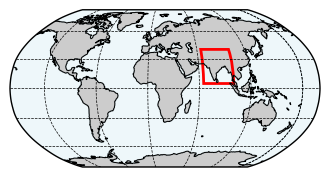

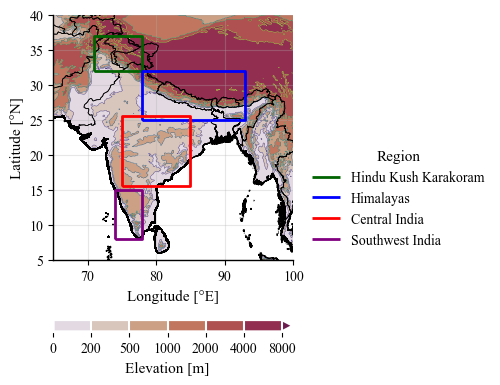

In [13]:
import matplotlib.ticker as mticker

cmap = cmr.get_sub_cmap('twilight_shifted', 0.5, 0.89)

# Creating the figure 1 for the global map
fig_1 = plt.figure(figsize=(4, 4))

# Adding subplot with global map
ax = fig_1.add_subplot(1, 1, 1, projection=ccrs.Robinson(central_longitude=20.0))
ax.set_global()
ax.coastlines(lw=0.7)

# ax.add_feature(cfeature.BORDERS, linestyle='-', lw=0.2)
ax.add_feature(cfeature.LAND, color='gray', alpha=0.4)
ax.add_feature(cfeature.OCEAN, color='lightblue', alpha=0.2)

# Add latitude and longitude grid lines
gl = ax.gridlines(draw_labels=False, linestyle='--', color='k', lw=0.5)


# Creating the figure 2 for the submaps
fig = plt.figure(figsize=(3, 4))
# Define extent of case study regions
regions = {
    "India": [65, 100, 5, 40],
}

# Function for adding sub-map
def add_inset(extent, loc, orography, levels, ax_to_hide):

    # Cutting orography in the right extent
    orog = orography.sel(latitude = slice(extent[3], extent[2]), longitude = slice(extent[0], extent[1]))
    orog = np.abs(orog)

    # Creating ax for sub map
    sub_ax = fig.add_axes(loc)

    # Plotting orography in submap
    orog_plot = orog.plot(ax=sub_ax, add_colorbar=False, levels=levels, cmap=cmap, extend='max')
    orog.plot.contour(ax=sub_ax, add_colorbar=False, levels=levels, color='k', linecolor='k', linewidths=0.3, alpha=1)


    sub_ax.set_title('')

    standard_format_single(orog_plot, None, None, True)

    print(orog_plot.colorbar)
    orog_plot.colorbar.set_label(r'Elevation [m]', fontsize=11)
    cbar = orog_plot.colorbar

    # Box on global map
    rect = Rectangle((extent[0], extent[2]), extent[1] - extent[0], extent[3] - extent[2],
                     linewidth=2, edgecolor='red', facecolor='none', transform=ccrs.PlateCarree())
    
    ax.add_patch(rect)

    sub_ax.set_xlim(extent[0], extent[1])
    sub_ax.set_ylim(extent[2], extent[3])

    sub_ax.set_xlabel('Longitude [°E]')
    sub_ax.set_ylabel('Latitude [°N]')

    coastline.plot(ax=sub_ax, color='k', lw=1)
    boundary.boundary.plot(ax=sub_ax, color='k', lw=0.5)
    hkk.boundary.plot(ax=sub_ax, color='darkgreen', lw=2, label='Hindu Kush Karakoram')
    him.boundary.plot(ax=sub_ax, color='blue', lw=2, label='Himalayas')
    central_india.boundary.plot(ax=sub_ax, color='red', lw=2, label='Central India')
    southwest_india.boundary.plot(ax=sub_ax, color='purple', lw=2, label='Southwest India')
    
    sub_ax.legend(loc='lower right', bbox_to_anchor=(1.85, 0),
          fontsize=10, frameon=False, ncol=1, title='Region', title_fontsize=11)

# Add inset maps
add_inset(regions["India"], [0.15, -0.8, 0.8, 1], orography, [0,200,500,1000,2000,4000,8000], ['top','right'])

# Save the figure using configured paths
(figures_path := FIGURES_DIR / 'ERA5_orography_INDIA.png')
fig.savefig(figures_path, dpi=300, bbox_inches='tight', transparent=True)
print(f"Saved figure to {figures_path}")